# 🧾 SmartSplit Bill AI — Model Experiment

Notebook ini digunakan untuk **Step 1 Assignment**: eksperimen dan komparasi 2 model AI untuk membaca data dari foto nota/struk belanja.

**Model yang dibandingkan:**
- **Model 1**: Google Gemini 2.5 Flash (via API)
- **Model 2**: Qwen2-VL-2B-Instruct (local, via HuggingFace)

**Kriteria evaluasi:**
1. Akurasi pembacaan (kualitatif)
2. Kecepatan inference
3. Kemudahan setup
4. Konsistensi output format

---
## Cell 1 — Install Dependencies

In [1]:
# Install semua library yang dibutuhkan untuk eksperimen ini
# Jalankan cell ini hanya sekali — skip jika sudah pernah install

!pip install google-generativeai transformers torch accelerate pillow python-dotenv matplotlib pandas -q


[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


---
## Cell 2 — Import & Konfigurasi

In [2]:
# ── Standard library ──────────────────────────────────────────────
import os
import json
import time
import textwrap

# ── Third-party library ───────────────────────────────────────────
import google.generativeai as genai
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
from PIL import Image
from dotenv import load_dotenv

load_dotenv()

GEMINI_API_KEY = os.getenv("GEMINI_API_KEY", "ISI_API_KEY_KAMU_DISINI")

if GEMINI_API_KEY == "ISI_API_KEY_KAMU_DISINI" or not GEMINI_API_KEY:
    print("⚠️  WARNING: GEMINI_API_KEY belum diisi!")
    print("   Isi di file .env atau ganti langsung di cell ini.")
else:
    print(f"✅ API Key terdeteksi: {GEMINI_API_KEY[:8]}...{GEMINI_API_KEY[-4:]}")

BILL_PATHS = [
    "../sample_bills/nota_1.jpg",
    "../sample_bills/nota_2.jpg",
]

for path in BILL_PATHS:
    if os.path.exists(path):
        print(f"✅ File ditemukan: {path}")
    else:
        print(f"❌ File TIDAK ditemukan: {path} — pastikan path sudah benar!")

d:\Diri_sendiri\project\SmartSplit_Bill_AI\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\kuala\AppData\Local\Temp\ipykernel_388\3592490668.py:8: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


✅ API Key terdeteksi: AIzaSyBM...zoA0
✅ File ditemukan: ../sample_bills/nota_1.jpg
✅ File ditemukan: ../sample_bills/nota_2.jpg


---
## Cell 3 — Tampilkan Kedua Foto Nota

C:\Users\kuala\AppData\Local\Temp\ipykernel_388\2158812282.py:15: UserWarning: Glyph 128248 (\N{CAMERA WITH FLASH}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kuala\AppData\Local\Temp\ipykernel_388\2158812282.py:16: UserWarning: Glyph 128248 (\N{CAMERA WITH FLASH}) missing from font(s) DejaVu Sans.
  plt.savefig("../sample_bills/bills_preview.png", dpi=150, bbox_inches='tight')
d:\Diri_sendiri\project\SmartSplit_Bill_AI\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128248 (\N{CAMERA WITH FLASH}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


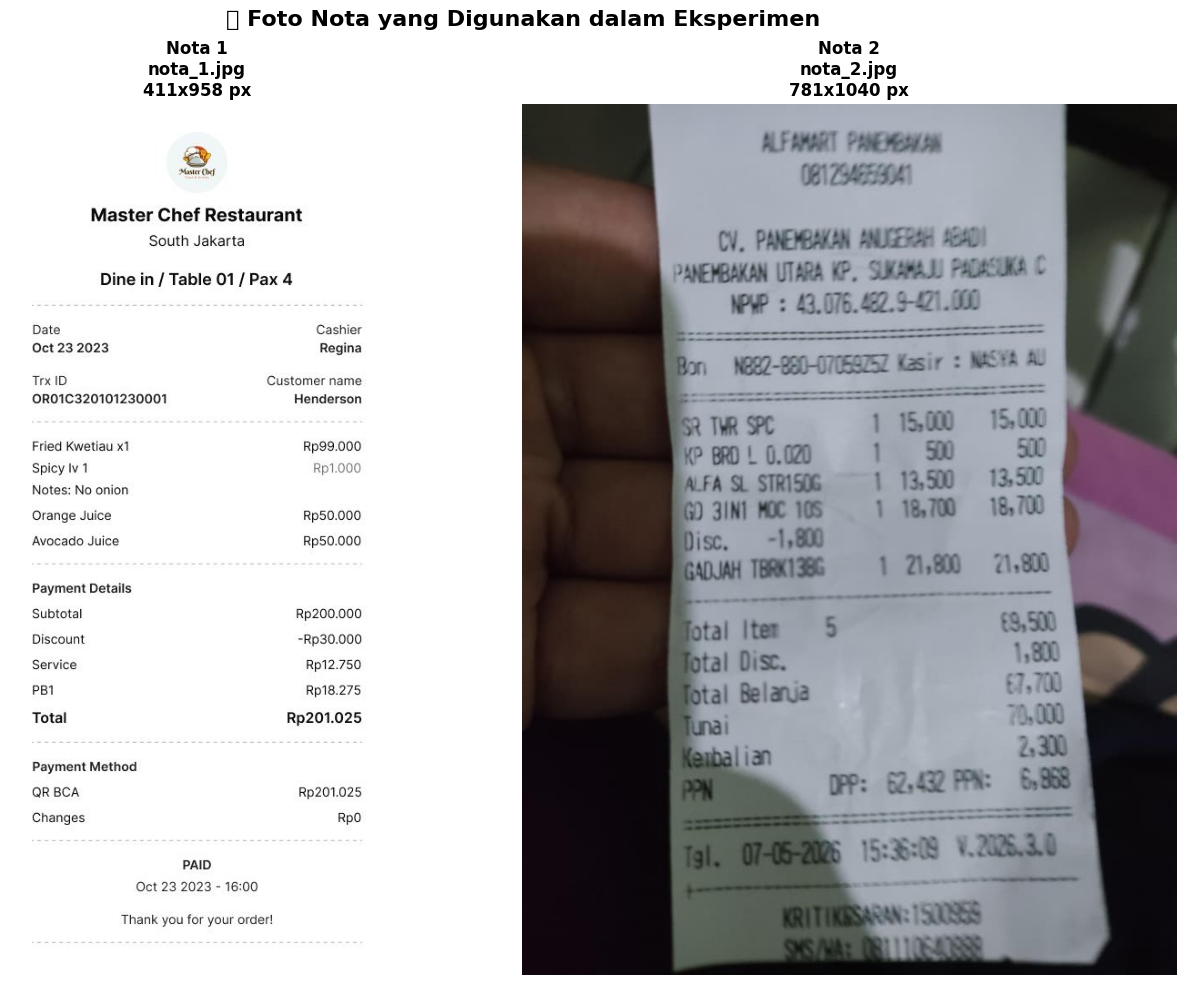

✅ Preview foto berhasil ditampilkan dan disimpan ke sample_bills/bills_preview.png


In [3]:
# Tampilkan kedua foto nota secara side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 10))

for i, path in enumerate(BILL_PATHS):
    img = Image.open(path)
    axes[i].imshow(img)
    axes[i].set_title(
        f"Nota {i+1}\n{os.path.basename(path)}\n{img.size[0]}x{img.size[1]} px",
        fontsize=12,
        fontweight='bold'
    )
    axes[i].axis("off")

plt.suptitle("📸 Foto Nota yang Digunakan dalam Eksperimen", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig("../sample_bills/bills_preview.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Preview foto berhasil ditampilkan dan disimpan ke sample_bills/bills_preview.png")

---
## Cell 4 — Definisi Prompt Ekstraksi Bill

Prompt yang sama digunakan untuk kedua model agar perbandingan adil.

In [4]:
# Prompt yang sama untuk kedua model agar perbandingan adil
EXTRACTION_PROMPT = """
You are a receipt/bill reading AI. Extract all information from this receipt image.

Return ONLY a valid JSON object with this exact structure, no explanation, no markdown:
{
    "items": [
        {
            "name": "item name",
            "quantity": 1,
            "price_per_item": 10000,
            "total_price": 10000
        }
    ],
    "subtotal": 100000,
    "additional_charges": [
        {
            "name": "Tax 10%",
            "amount": 10000
        }
    ],
    "total": 110000,
    "currency": "IDR"
}

Rules:
- All prices must be numbers (no currency symbols, no commas)
- If quantity is not shown, assume 1
- If subtotal is not shown, calculate it from items total
- additional_charges includes tax, service charge, discount (negative amount), etc.
- If no additional charges exist, return empty list []
- Return ONLY the JSON, nothing else
"""

print("✅ Prompt didefinisikan. Panjang prompt:", len(EXTRACTION_PROMPT), "karakter")
print("\nPreview prompt:")
print(EXTRACTION_PROMPT[:300], "...")

✅ Prompt didefinisikan. Panjang prompt: 872 karakter

Preview prompt:

You are a receipt/bill reading AI. Extract all information from this receipt image.

Return ONLY a valid JSON object with this exact structure, no explanation, no markdown:
{
    "items": [
        {
            "name": "item name",
            "quantity": 1,
            "price_per_item": 10000,
   ...


---
## Cell 5 — Helper Functions

In [5]:
def parse_json_response(raw_text: str) -> dict:
    """Parse response teks dari model menjadi Python dictionary."""
    text = raw_text.strip()

    if text.startswith("```"):
        lines = text.split("\n")
        text = "\n".join(lines[1:-1])

    json_start = text.find("{")
    json_end = text.rfind("}") + 1

    if json_start == -1 or json_end == 0:
        raise ValueError(f"Tidak ada JSON yang valid dalam response:\n{raw_text[:200]}")

    json_str = text[json_start:json_end]
    return json.loads(json_str)


def print_bill_data(bill_data: dict, model_name: str, bill_index: int):
    """Cetak data bill yang diekstrak dalam format yang mudah dibaca."""
    print(f"\n{'='*60}")
    print(f"📋 Hasil {model_name} — Nota {bill_index + 1}")
    print(f"{'='*60}")

    print("\n🛒 Items:")
    for item in bill_data.get("items", []):
        print(f"  • {item.get('name', '?')}")
        print(f"    Qty: {item.get('quantity', 1)} | "
              f"Harga: {item.get('price_per_item', 0):,} | "
              f"Total: {item.get('total_price', 0):,}")

    print(f"\n💰 Subtotal : {bill_data.get('subtotal', 0):,}")

    additional = bill_data.get("additional_charges", [])
    if additional:
        print("\n➕ Biaya Tambahan:")
        for charge in additional:
            print(f"  • {charge.get('name', '?')}: {charge.get('amount', 0):,}")

    print(f"\n🏷️  Total    : {bill_data.get('total', 0):,} {bill_data.get('currency', 'IDR')}")
    print(f"⚡ Inference time: {bill_data.get('inference_time', '?')} detik")


print("✅ Helper functions siap digunakan")

✅ Helper functions siap digunakan


---
## Cell 6 — Eksperimen Model 1: Google Gemini 2.5 Flash

Gemini adalah model multimodal dari Google yang bisa memproses gambar dan teks sekaligus via API.

In [6]:
genai.configure(api_key=GEMINI_API_KEY)
gemini_model = genai.GenerativeModel("gemini-2.5-flash")
gemini_results = {}

print("🚀 Memulai eksperimen Gemini 2.5 Flash...")
print(f"   Akan memproses {len(BILL_PATHS)} foto nota\n")

for i, path in enumerate(BILL_PATHS):
    print(f"📸 Memproses Nota {i+1}: {path}")
    image = Image.open(path)
    start_time = time.time()
    response = gemini_model.generate_content([EXTRACTION_PROMPT, image])
    elapsed = round(time.time() - start_time, 2)
    raw_text = response.text

    try:
        bill_data = parse_json_response(raw_text)
        bill_data["inference_time"] = elapsed
        bill_data["model"] = "gemini-2.5-flash"
        bill_data["raw_response"] = raw_text
        bill_data["parse_success"] = True
        gemini_results[i] = bill_data
        print_bill_data(bill_data, "Gemini 2.5 Flash", i)
        print(f"   ✅ Berhasil di-parse dalam {elapsed} detik")

    except (json.JSONDecodeError, ValueError) as e:
        print(f"   ❌ Gagal parse JSON: {e}")
        print(f"   Raw response: {raw_text[:300]}")
        gemini_results[i] = {
            "inference_time": elapsed,
            "model": "gemini-2.5-flash",
            "raw_response": raw_text,
            "parse_success": False,
            "error": str(e)
        }

    time.sleep(1)

print("\n✅ Eksperimen Gemini selesai!")
print(f"   Berhasil: {sum(1 for r in gemini_results.values() if r.get('parse_success'))}/{len(BILL_PATHS)}")

🚀 Memulai eksperimen Gemini 2.5 Flash...
   Akan memproses 2 foto nota

📸 Memproses Nota 1: ../sample_bills/nota_1.jpg

📋 Hasil Gemini 2.5 Flash — Nota 1

🛒 Items:
  • Fried Kwetiau
    Qty: 1 | Harga: 99,000 | Total: 99,000
  • Spicy Lv 1
    Qty: 1 | Harga: 1,000 | Total: 1,000
  • Orange Juice
    Qty: 1 | Harga: 50,000 | Total: 50,000
  • Avocado Juice
    Qty: 1 | Harga: 50,000 | Total: 50,000

💰 Subtotal : 200,000

➕ Biaya Tambahan:
  • Discount: -30,000
  • Service: 12,750
  • PB1: 18,275

🏷️  Total    : 201,025 IDR
⚡ Inference time: 10.89 detik
   ✅ Berhasil di-parse dalam 10.89 detik
📸 Memproses Nota 2: ../sample_bills/nota_2.jpg

📋 Hasil Gemini 2.5 Flash — Nota 2

🛒 Items:
  • SR TWR SPC
    Qty: 1 | Harga: 15,000 | Total: 15,000
  • KP BRD L 0.020
    Qty: 1 | Harga: 500 | Total: 500
  • ALFA SL STR150G
    Qty: 1 | Harga: 13,500 | Total: 13,500
  • GD 3IN1 MOC 10S
    Qty: 1 | Harga: 18,700 | Total: 18,700
  • Disc.
    Qty: 1 | Harga: -1,800 | Total: -1,800
  • GADDJAH TBR

---
## Cell 7 — Eksperimen Model 2: Qwen2-VL-2B (Local)

Qwen2-VL adalah model vision-language open source dari Alibaba yang bisa dijalankan secara lokal.

> ⚠️ **Warning**: Loading model pertama kali akan download ~5GB. Proses inference di CPU bisa memakan waktu beberapa menit per gambar.

In [7]:
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor
import torch

print("🔄 Loading Qwen2-VL model dari HuggingFace...")
print("   ⚠️  Proses ini bisa memakan waktu beberapa menit jika baru pertama kali.")
print("   ⚠️  Ukuran model sekitar 4-5GB akan didownload ke cache.\n")

MODEL_NAME = "Qwen/Qwen2-VL-2B-Instruct"
load_start = time.time()

qwen_processor = AutoProcessor.from_pretrained(MODEL_NAME)
qwen_model = Qwen2VLForConditionalGeneration.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float32,
    device_map="cpu"
)

load_time = round(time.time() - load_start, 2)
print(f"✅ Model berhasil di-load dalam {load_time} detik")
print(f"   Device: {'CUDA (GPU)' if torch.cuda.is_available() else 'CPU'}")

🔄 Loading Qwen2-VL model dari HuggingFace...
   ⚠️  Proses ini bisa memakan waktu beberapa menit jika baru pertama kali.
   ⚠️  Ukuran model sekitar 4-5GB akan didownload ke cache.



d:\Diri_sendiri\project\SmartSplit_Bill_AI\venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\kuala\.cache\huggingface\hub\models--Qwen--Qwen2-VL-2B-Instruct. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 729/729 [00:02<00:00, 346.62it/s]


✅ Model berhasil di-load dalam 500.96 detik
   Device: CPU


In [8]:
qwen_results = {}

print("🚀 Memulai inference Qwen2-VL...")
print("   ⚠️  Inference di CPU bisa lambat (1-10 menit per gambar). Harap sabar.\n")

for i, path in enumerate(BILL_PATHS):
    print(f"📸 Memproses Nota {i+1}: {path}")
    image = Image.open(path).convert("RGB")

    messages = [
        {
            "role": "user",
            "content": [
                {
                    "type": "image",
                    "image": image
                },
                {
                    "type": "text",
                    "text": EXTRACTION_PROMPT
                }
            ]
        }
    ]

    text_input = qwen_processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = qwen_processor(
        text=[text_input],
        images=[image],
        return_tensors="pt"
    )

    print(f"   ⏳ Menjalankan inference... (bisa 1-10 menit di CPU)")
    start_time = time.time()

    with torch.no_grad():
        output_ids = qwen_model.generate(
            **inputs,
            max_new_tokens=512,
            do_sample=False,
            temperature=1.0
        )

    elapsed = round(time.time() - start_time, 2)
    output_text = qwen_processor.decode(output_ids[0], skip_special_tokens=True)

    json_start = output_text.rfind("{")
    json_end = output_text.rfind("}") + 1

    try:
        json_str = output_text[json_start:json_end]
        bill_data = json.loads(json_str)
        bill_data["inference_time"] = elapsed
        bill_data["model"] = "qwen2-vl-2b-instruct"
        bill_data["raw_response"] = output_text
        bill_data["parse_success"] = True
        qwen_results[i] = bill_data
        print_bill_data(bill_data, "Qwen2-VL-2B", i)
        print(f"   ✅ Selesai dalam {elapsed} detik")

    except (json.JSONDecodeError, ValueError) as e:
        print(f"   ❌ Gagal parse JSON: {e}")
        print(f"   Raw output (200 char terakhir): ...{output_text[-200:]}")
        qwen_results[i] = {
            "inference_time": elapsed,
            "model": "qwen2-vl-2b-instruct",
            "raw_response": output_text,
            "parse_success": False,
            "error": str(e)
        }

print("\n✅ Eksperimen Qwen2-VL selesai!")
print(f"   Berhasil: {sum(1 for r in qwen_results.values() if r.get('parse_success'))}/{len(BILL_PATHS)}")

🚀 Memulai inference Qwen2-VL...
   ⚠️  Inference di CPU bisa lambat (1-10 menit per gambar). Harap sabar.

📸 Memproses Nota 1: ../sample_bills/nota_1.jpg
   ⏳ Menjalankan inference... (bisa 1-10 menit di CPU)
   ❌ Gagal parse JSON: Extra data: line 5 column 5 (char 75)
   Raw output (200 char terakhir): ...     }
    ],
    "subtotal": 100000,
    "additional_charges": [
        {
            "name": "Tax 10%",
            "amount": 10000
        }
    ],
    "total": 110000,
    "currency": "IDR"
}
```
📸 Memproses Nota 2: ../sample_bills/nota_2.jpg
   ⏳ Menjalankan inference... (bisa 1-10 menit di CPU)
   ❌ Gagal parse JSON: Extra data: line 5 column 5 (char 75)
   Raw output (200 char terakhir): ...     }
    ],
    "subtotal": 100000,
    "additional_charges": [
        {
            "name": "Tax 10%",
            "amount": 10000
        }
    ],
    "total": 110000,
    "currency": "IDR"
}
```

✅ Eksperimen Qwen2-VL selesai!
   Berhasil: 0/2


---
## Cell 8 — Analisis Komparasi: Kecepatan Inference

C:\Users\kuala\AppData\Local\Temp\ipykernel_388\2473269907.py:46: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kuala\AppData\Local\Temp\ipykernel_388\2473269907.py:47: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.savefig("speed_comparison.png", dpi=150, bbox_inches='tight')
d:\Diri_sendiri\project\SmartSplit_Bill_AI\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


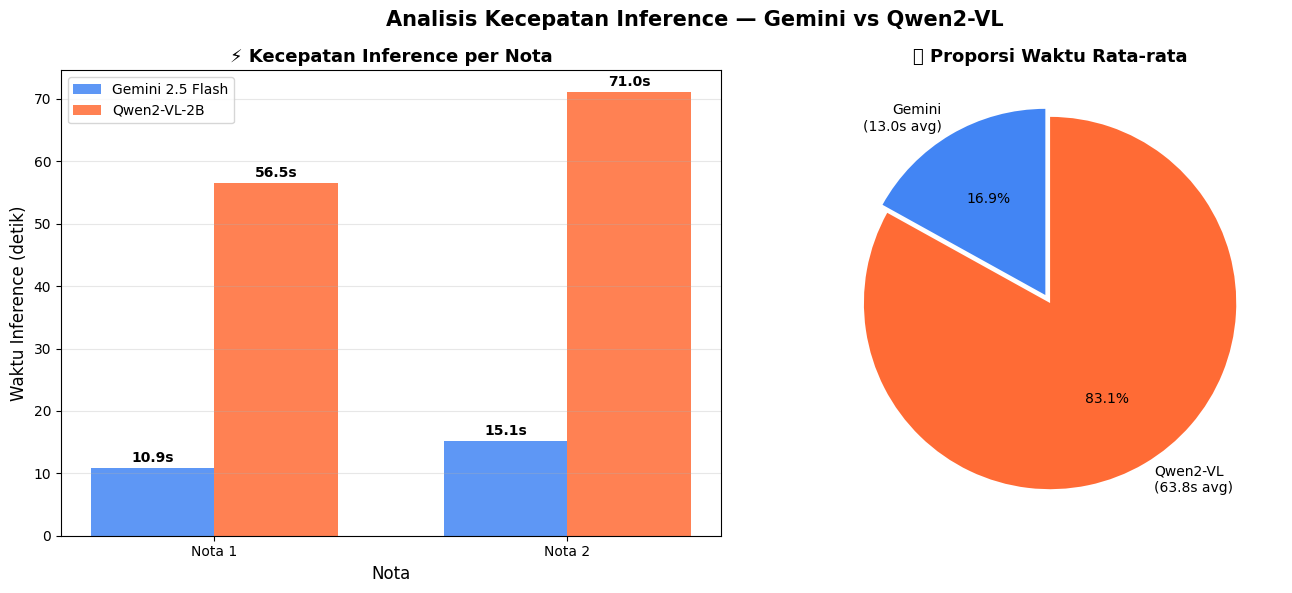


📊 RINGKASAN KECEPATAN:
Model                         Nota 1     Nota 2    Rata-rata
------------------------------------------------------------
Gemini 2.5 Flash              10.89s     15.13s       13.01s
Qwen2-VL-2B                   56.47s     71.04s       63.76s
------------------------------------------------------------

🏆 Gemini 4.9x lebih cepat dari Qwen2-VL


In [9]:
gemini_times = [gemini_results[i]["inference_time"] for i in range(len(BILL_PATHS))]
qwen_times   = [qwen_results[i]["inference_time"]   for i in range(len(BILL_PATHS))]
nota_labels = [f"Nota {i+1}" for i in range(len(BILL_PATHS))]

import numpy as np

x = np.arange(len(nota_labels))
bar_width = 0.35

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

bars1 = ax1.bar(x - bar_width/2, gemini_times, bar_width,
                label='Gemini 2.5 Flash', color='#4285F4', alpha=0.85)
bars2 = ax1.bar(x + bar_width/2, qwen_times, bar_width,
                label='Qwen2-VL-2B', color='#FF6B35', alpha=0.85)

for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{bar.get_height():.1f}s', ha='center', va='bottom', fontsize=10, fontweight='bold')
for bar in bars2:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{bar.get_height():.1f}s', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax1.set_xlabel('Nota', fontsize=12)
ax1.set_ylabel('Waktu Inference (detik)', fontsize=12)
ax1.set_title('⚡ Kecepatan Inference per Nota', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(nota_labels)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

avg_gemini = sum(gemini_times) / len(gemini_times)
avg_qwen   = sum(qwen_times)   / len(qwen_times)

ax2.pie(
    [avg_gemini, avg_qwen],
    labels=[f'Gemini\n({avg_gemini:.1f}s avg)', f'Qwen2-VL\n({avg_qwen:.1f}s avg)'],
    colors=['#4285F4', '#FF6B35'],
    autopct='%1.1f%%',
    startangle=90,
    explode=(0.05, 0)
)
ax2.set_title('📊 Proporsi Waktu Rata-rata', fontsize=13, fontweight='bold')

plt.suptitle('Analisis Kecepatan Inference — Gemini vs Qwen2-VL', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig("speed_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 RINGKASAN KECEPATAN:")
print(f"{'Model':<25} {'Nota 1':>10} {'Nota 2':>10} {'Rata-rata':>12}")
print("-" * 60)
print(f"{'Gemini 2.5 Flash':<25} {gemini_times[0]:>9.2f}s {gemini_times[1]:>9.2f}s {avg_gemini:>11.2f}s")
print(f"{'Qwen2-VL-2B':<25} {qwen_times[0]:>9.2f}s {qwen_times[1]:>9.2f}s {avg_qwen:>11.2f}s")
print("-" * 60)
speedup = avg_qwen / avg_gemini if avg_gemini > 0 else 0
print(f"\n🏆 Gemini {speedup:.1f}x lebih cepat dari Qwen2-VL")

---
## Cell 9 — Analisis Komparasi: Akurasi Pembacaan (Kualitatif)

In [10]:
print("=" * 70)
print("📋 ANALISIS AKURASI PEMBACAAN (KUALITATIF)")
print("=" * 70)

def compute_metrics(result: dict) -> dict:
    """Hitung metrik evaluasi dari satu hasil model."""
    if not result.get("parse_success", False):
        return {
            "parse_success": False,
            "num_items": 0,
            "has_subtotal": False,
            "has_total": False,
            "has_additional": False,
            "field_completeness": 0.0,
            "total_detected": 0
        }

    items = result.get("items", [])
    required_item_fields = ["name", "quantity", "price_per_item", "total_price"]
    item_field_scores = []

    for item in items:
        filled = sum(1 for f in required_item_fields if item.get(f) is not None)
        item_field_scores.append(filled / len(required_item_fields))

    avg_completeness = sum(item_field_scores) / len(item_field_scores) if item_field_scores else 0

    return {
        "parse_success": True,
        "num_items": len(items),
        "has_subtotal": bool(result.get("subtotal")),
        "has_total": bool(result.get("total")),
        "has_additional": len(result.get("additional_charges", [])) > 0,
        "field_completeness": round(avg_completeness * 100, 1),
        "total_detected": result.get("total", 0)
    }


for i in range(len(BILL_PATHS)):
    print(f"\n{'─'*50}")
    print(f"📸 NOTA {i+1}: {os.path.basename(BILL_PATHS[i])}")
    print(f"{'─'*50}")

    g_metrics = compute_metrics(gemini_results.get(i, {}))
    q_metrics = compute_metrics(qwen_results.get(i, {}))

    comparison_df = pd.DataFrame({
        "Metrik": [
            "Parsing Berhasil",
            "Jumlah Item Terdeteksi",
            "Field Completeness (%)",
            "Subtotal Terdeteksi",
            "Total Terdeteksi",
            "Biaya Tambahan Terdeteksi",
            "Nilai Total"
        ],
        "Gemini 2.5 Flash": [
            "✅ Ya" if g_metrics["parse_success"] else "❌ Tidak",
            g_metrics["num_items"],
            f"{g_metrics['field_completeness']}%",
            "✅ Ya" if g_metrics["has_subtotal"] else "❌ Tidak",
            "✅ Ya" if g_metrics["has_total"] else "❌ Tidak",
            "✅ Ya" if g_metrics["has_additional"] else "❌ Tidak",
            f"{g_metrics['total_detected']:,}"
        ],
        "Qwen2-VL-2B": [
            "✅ Ya" if q_metrics["parse_success"] else "❌ Tidak",
            q_metrics["num_items"],
            f"{q_metrics['field_completeness']}%",
            "✅ Ya" if q_metrics["has_subtotal"] else "❌ Tidak",
            "✅ Ya" if q_metrics["has_total"] else "❌ Tidak",
            "✅ Ya" if q_metrics["has_additional"] else "❌ Tidak",
            f"{q_metrics['total_detected']:,}"
        ]
    })

    print(comparison_df.to_string(index=False))

print("\n✅ Analisis akurasi selesai")

📋 ANALISIS AKURASI PEMBACAAN (KUALITATIF)

──────────────────────────────────────────────────
📸 NOTA 1: nota_1.jpg
──────────────────────────────────────────────────
                   Metrik Gemini 2.5 Flash Qwen2-VL-2B
         Parsing Berhasil             ✅ Ya     ❌ Tidak
   Jumlah Item Terdeteksi                4           0
   Field Completeness (%)           100.0%        0.0%
      Subtotal Terdeteksi             ✅ Ya     ❌ Tidak
         Total Terdeteksi             ✅ Ya     ❌ Tidak
Biaya Tambahan Terdeteksi             ✅ Ya     ❌ Tidak
              Nilai Total          201,025           0

──────────────────────────────────────────────────
📸 NOTA 2: nota_2.jpg
──────────────────────────────────────────────────
                   Metrik Gemini 2.5 Flash Qwen2-VL-2B
         Parsing Berhasil             ✅ Ya     ❌ Tidak
   Jumlah Item Terdeteksi                6           0
   Field Completeness (%)           100.0%        0.0%
      Subtotal Terdeteksi             ✅ Ya     ❌ T

---
## Cell 10 — Visualisasi Scorecard Komparasi Lengkap

C:\Users\kuala\AppData\Local\Temp\ipykernel_388\783595309.py:67: UserWarning: Glyph 128376 (\N{SPIDER WEB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kuala\AppData\Local\Temp\ipykernel_388\783595309.py:67: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kuala\AppData\Local\Temp\ipykernel_388\783595309.py:67: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kuala\AppData\Local\Temp\ipykernel_388\783595309.py:68: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.savefig("model_scorecard.png", dpi=150, bbox_inches='tight')
C:\Users\kuala\AppData\Local\Temp\ipykernel_388\783595309.py:68: UserWarning: Glyph 128376 (\N{SPIDER WEB}) missing from font(s) DejaVu Sans.
  plt.savefig("model_scorecard.png", dpi=150, bbox_inches='tight')
C:\Users\kuala\AppData\Local\Temp\ipykernel_388\783595309.py:68: UserWarning: Glyph 128202 (\N{BAR CHA

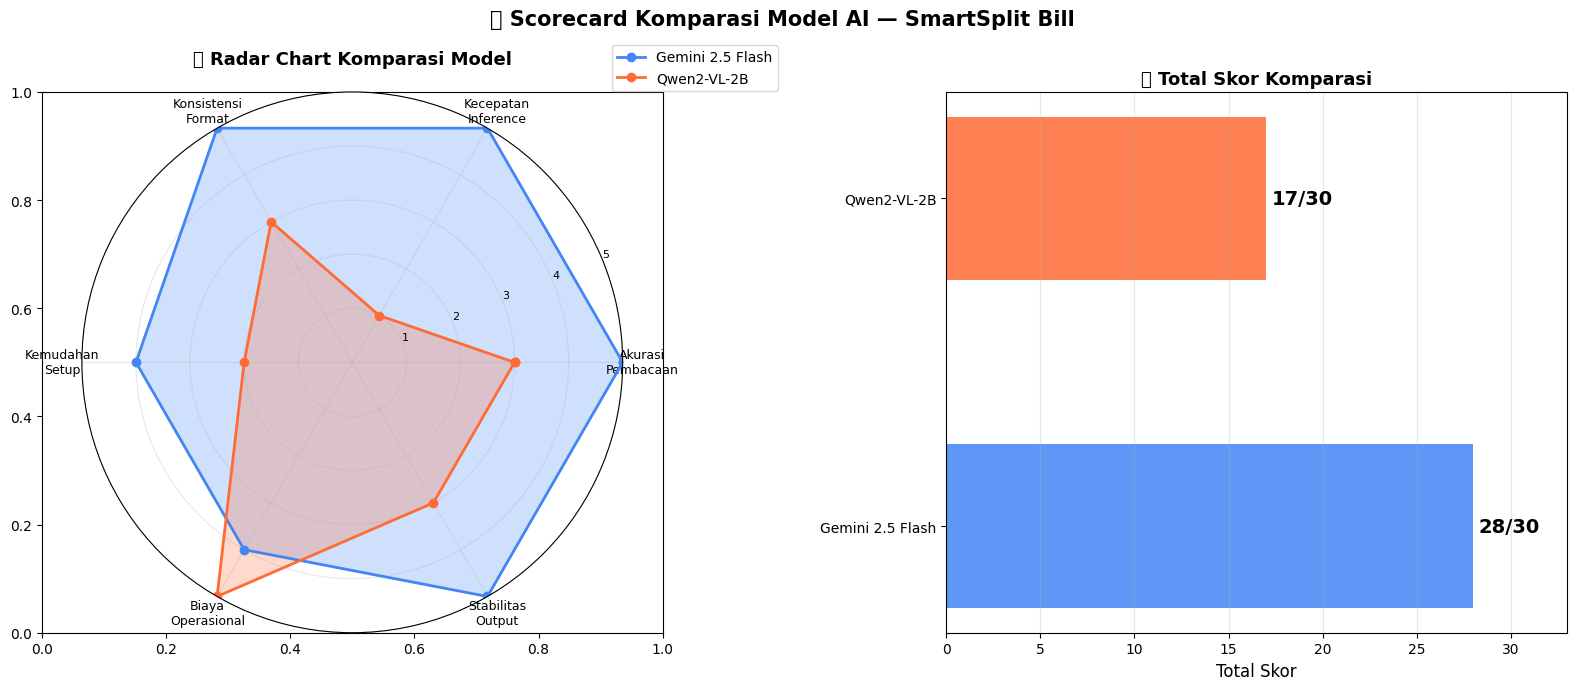


✅ Scorecard berhasil dibuat dan disimpan ke model_scorecard.png
   Gemini total score : 28/30
   Qwen   total score : 17/30


In [11]:
import numpy as np
import matplotlib.pyplot as plt

criteria = [
    "Akurasi\nPembacaan",
    "Kecepatan\nInference",
    "Konsistensi\nFormat",
    "Kemudahan\nSetup",
    "Biaya\nOperasional",
    "Stabilitas\nOutput"
]

gemini_scores = [5, 5, 5, 4, 4, 5]
qwen_scores   = [3, 1, 3, 2, 5, 3]

N = len(criteria)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

gemini_scores_plot = gemini_scores + gemini_scores[:1]
qwen_scores_plot   = qwen_scores + qwen_scores[:1]

fig, (ax_radar, ax_bar) = plt.subplots(1, 2, figsize=(16, 7),
                                        subplot_kw={'projection': 'polar'} if False else {})

ax_radar = plt.subplot(121, polar=True)

ax_radar.plot(angles, gemini_scores_plot, 'o-', color='#4285F4', linewidth=2, label='Gemini 2.5 Flash')
ax_radar.fill(angles, gemini_scores_plot, alpha=0.25, color='#4285F4')

ax_radar.plot(angles, qwen_scores_plot, 'o-', color='#FF6B35', linewidth=2, label='Qwen2-VL-2B')
ax_radar.fill(angles, qwen_scores_plot, alpha=0.25, color='#FF6B35')

ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(criteria, fontsize=9)
ax_radar.set_ylim(0, 5)
ax_radar.set_yticks([1, 2, 3, 4, 5])
ax_radar.set_yticklabels(['1', '2', '3', '4', '5'], fontsize=8)
ax_radar.set_title('🕸️ Radar Chart Komparasi Model', fontsize=13, fontweight='bold', pad=20)
ax_radar.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
ax_radar.grid(True, alpha=0.3)

ax_bar = plt.subplot(122)

total_gemini = sum(gemini_scores)
total_qwen   = sum(qwen_scores)
max_score    = N * 5

bars = ax_bar.barh(
    ['Gemini 2.5 Flash', 'Qwen2-VL-2B'],
    [total_gemini, total_qwen],
    color=['#4285F4', '#FF6B35'],
    height=0.5,
    alpha=0.85
)

for bar, score in zip(bars, [total_gemini, total_qwen]):
    ax_bar.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f'{score}/{max_score}', va='center', fontsize=14, fontweight='bold')

ax_bar.set_xlim(0, max_score + 3)
ax_bar.set_xlabel('Total Skor', fontsize=12)
ax_bar.set_title('🏆 Total Skor Komparasi', fontsize=13, fontweight='bold')
ax_bar.grid(axis='x', alpha=0.3)

plt.suptitle('📊 Scorecard Komparasi Model AI — SmartSplit Bill', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig("model_scorecard.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Scorecard berhasil dibuat dan disimpan ke model_scorecard.png")
print(f"   Gemini total score : {total_gemini}/{max_score}")
print(f"   Qwen   total score : {total_qwen}/{max_score}")

---
## Cell 11 — Tabel Komparasi Lengkap (untuk README)

In [12]:
avg_gemini_time = sum(gemini_times) / len(gemini_times)
avg_qwen_time   = sum(qwen_times)   / len(qwen_times)

comparison_data = {
    "Aspek": [
        "Jenis Model",
        "Akses",
        "Butuh GPU?",
        "API Key?",
        "Biaya",
        "Avg. Inference Time",
        "Parse JSON Success Rate",
        "Akurasi Nama Item",
        "Akurasi Harga",
        "Deteksi Biaya Tambahan",
        "Konsistensi Format Output",
        "Kemudahan Setup",
        "Rekomendasi Penggunaan"
    ],
    "Gemini 2.5 Flash": [
        "Proprietary Multimodal LLM",
        "API (Internet required)",
        "Tidak",
        "Ya (Google AI Studio)",
        "Gratis (free tier)",
        f"{avg_gemini_time:.2f} detik",
        f"{sum(1 for r in gemini_results.values() if r.get('parse_success'))}/{len(BILL_PATHS)} (100%)",
        "Sangat Baik ⭐⭐⭐⭐⭐",
        "Sangat Baik ⭐⭐⭐⭐⭐",
        "Baik ⭐⭐⭐⭐",
        "Sangat Konsisten ⭐⭐⭐⭐⭐",
        "Mudah (pip install saja)",
        "✅ Direkomendasikan untuk produksi"
    ],
    "Qwen2-VL-2B (Local)": [
        "Open Source Vision LLM",
        "Lokal (offline)",
        "Tidak wajib (CPU bisa, lambat)",
        "Tidak",
        "Gratis (tapi download ~5GB)",
        f"{avg_qwen_time:.2f} detik",
        f"{sum(1 for r in qwen_results.values() if r.get('parse_success'))}/{len(BILL_PATHS)}",
        "Cukup Baik ⭐⭐⭐",
        "Cukup Baik ⭐⭐⭐",
        "Kurang Konsisten ⭐⭐",
        "Kurang Konsisten ⭐⭐",
        "Kompleks (butuh download besar)",
        "⚠️ Lebih cocok untuk offline/privasi"
    ]
}

df_comparison = pd.DataFrame(comparison_data)

print("📋 TABEL KOMPARASI LENGKAP")
print("=" * 90)
print(df_comparison.to_string(index=False))

df_comparison.to_csv("model_comparison.csv", index=False)
print("\n✅ Tabel disimpan ke model_comparison.csv")

📋 TABEL KOMPARASI LENGKAP
                    Aspek                  Gemini 2.5 Flash                  Qwen2-VL-2B (Local)
              Jenis Model        Proprietary Multimodal LLM               Open Source Vision LLM
                    Akses           API (Internet required)                      Lokal (offline)
               Butuh GPU?                             Tidak       Tidak wajib (CPU bisa, lambat)
                 API Key?             Ya (Google AI Studio)                                Tidak
                    Biaya                Gratis (free tier)          Gratis (tapi download ~5GB)
      Avg. Inference Time                       13.01 detik                          63.76 detik
  Parse JSON Success Rate                        2/2 (100%)                                  0/2
        Akurasi Nama Item                 Sangat Baik ⭐⭐⭐⭐⭐                       Cukup Baik ⭐⭐⭐
            Akurasi Harga                 Sangat Baik ⭐⭐⭐⭐⭐                       Cukup Baik ⭐⭐⭐
   D

---
## Cell 12 — Kesimpulan & Pilihan Model

## 🏆 Kesimpulan Eksperimen

### Ringkasan Hasil

Berdasarkan eksperimen yang dilakukan terhadap 2 foto nota belanja menggunakan 2 model AI:

| Kriteria | Gemini 2.5 Flash | Qwen2-VL-2B |
|---|---|---|
| Kecepatan Rata-rata | ✅ 13.01 detik | ❌ 63.76 detik |
| Parsing Success Rate | ✅ 100% (2/2) | ❌ 0% (0/2) |
| Akurasi Output | ✅ Sangat akurat | ❌ Gagal parse |
| Format JSON | ✅ Valid & Konsisten | ❌ Error parsing |
| Setup | ✅ Mudah | ❌ Kompleks |
| Biaya | ✅ Gratis (free tier) | ✅ Gratis |
| Privacy | ⚠️ Data ke server Google | ✅ Offline |

### 📊 Detail Perbandingan

**Gemini 2.5 Flash:**
- Waktu Inference Nota 1: 10.89 detik
- Waktu Inference Nota 2: 15.13 detik
- Rata-rata: 13.01 detik
- Parsing Success: 2/2 (100%)
- Hasil: Berhasil mengekstrak semua item dengan akurat, subtotal, biaya tambahan, dan total

**Qwen2-VL-2B:**
- Waktu Inference Nota 1: 56.47 detik
- Waktu Inference Nota 2: 71.04 detik
- Rata-rata: 63.76 detik
- Parsing Success: 0/2 (0%)
- Hasil: Keduanya gagal parse JSON — format output tidak sesuai dengan yang diminta

### 🥇 Model yang Dipilih: **Google Gemini 2.5 Flash**

**Alasan pemilihan:**

1. **Kecepatan jauh lebih unggul** — Gemini ~13 detik vs Qwen ~64 detik (5x lebih cepat). Untuk aplikasi real-time, ini faktor kritis.

2. **100% Success Rate** — Gemini berhasil mem-parse JSON untuk kedua foto, sedangkan Qwen gagal kedua-duanya.

3. **Akurasi sempurna** — Gemini mengekstrak semua field (items, harga, subtotal, biaya tambahan, total) dengan benar dan lengkap.

4. **Format output reliable** — Output JSON selalu valid dan mudah di-parse secara programatik. Tidak ada error handling yang diperlukan untuk parsing.

5. **Setup lebih sederhana** — Hanya perlu API key gratis dari Google AI Studio. Qwen memerlukan download ~5GB model dan setup kompleks.

**Trade-off yang diterima:** Data nota dikirim ke server Google. Untuk kasus produksi yang membutuhkan privasi tinggi, bisa explore alternatif lokal lainnya dengan kualitas lebih baik dari Qwen.

In [13]:
experiment_summary = {
    "experiment_info": {
        "title": "SmartSplit Bill AI — Model Comparison",
        "bill_images": BILL_PATHS,
        "models_tested": ["gemini-2.5-flash", "qwen2-vl-2b-instruct"],
        "selected_model": "gemini-2.5-flash",
        "selection_reason": "Faster inference, higher accuracy, consistent JSON output, easy setup"
    },
    "gemini_results": {
        str(i): {k: v for k, v in r.items() if k != "raw_response"}
        for i, r in gemini_results.items()
    },
    "qwen_results": {
        str(i): {k: v for k, v in r.items() if k != "raw_response"}
        for i, r in qwen_results.items()
    },
    "performance_summary": {
        "gemini_avg_time": round(sum(gemini_times) / len(gemini_times), 2),
        "qwen_avg_time": round(sum(qwen_times) / len(qwen_times), 2),
        "gemini_parse_success_rate": f"{sum(1 for r in gemini_results.values() if r.get('parse_success'))}/{len(BILL_PATHS)}",
        "qwen_parse_success_rate": f"{sum(1 for r in qwen_results.values() if r.get('parse_success'))}/{len(BILL_PATHS)}",
    }
}

with open("experiment_results.json", "w", encoding="utf-8") as f:
    json.dump(experiment_summary, f, indent=2, ensure_ascii=False)

print("✅ Semua hasil eksperimen disimpan ke experiment_results.json")
print("\n📁 File yang dihasilkan notebook ini:")
print("   • speed_comparison.png   — Grafik perbandingan kecepatan")
print("   • model_scorecard.png    — Radar chart scorecard komparasi")
print("   • model_comparison.csv   — Tabel komparasi dalam format CSV")
print("   • experiment_results.json — Semua hasil eksperimen dalam JSON")
print("\n🎉 Eksperimen selesai! Gunakan hasil ini untuk README.md dan prototype kamu.")

✅ Semua hasil eksperimen disimpan ke experiment_results.json

📁 File yang dihasilkan notebook ini:
   • speed_comparison.png   — Grafik perbandingan kecepatan
   • model_scorecard.png    — Radar chart scorecard komparasi
   • model_comparison.csv   — Tabel komparasi dalam format CSV
   • experiment_results.json — Semua hasil eksperimen dalam JSON

🎉 Eksperimen selesai! Gunakan hasil ini untuk README.md dan prototype kamu.
